# Notebook 06 — End-to-End Pipeline Evaluation
Simulate the full WAF pipeline (L1 → L2A → L2B → Threat Score) on the test set. Measure overall detection rate, FPR, and latency.

This produces the final numbers for your project report.

In [1]:
# ── Mount Drive ──────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys, os

# ── Point Python at your project files ───────────────────────
PROJECT = '/content/drive/MyDrive/waf-ml-project/ml'
sys.path.insert(0, PROJECT)           # so   import feature_engineering   works
os.chdir(PROJECT)                     # so   Path("../data/...")   resolves
print(f"Working dir: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working dir: /content/drive/MyDrive/waf-ml-project/ml


In [13]:
 %%capture
 !pip install -r /content/drive/MyDrive/waf-ml-project/ml/requirements_train.txt # run once

In [14]:
%%capture
!pip install scikit-learn xgboost torch onnx onnxruntime \
             skl2onnx mlflow tqdm seaborn scipy pandas openpyxl

In [15]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import onnxruntime as ort
import time, re, json, scipy.special
from pathlib import Path
from sklearn.model_selection import train_test_split

from feature_engineering.extractor import extract_features, to_vector, FEATURE_NAMES
from feature_engineering.tokenizer import CharTokenizer
from feature_engineering.normalizer import Normalizer

SPLITS    = Path("../data/splits")
EXPORTS   = Path("../exported_models")
DATA_PROC = Path("../data/processed")

CLASS_NAMES = ["normal", "sqli", "xss", "lfi", "other_attack"]

# Load the balanced dataset (needed to rebuild idx_te)
df = pd.read_csv(DATA_PROC / "csic_parsed.csv")
print(f"Loaded {len(df):,} rows from csic_parsed.csv")
print(df["attack_class"].value_counts())


Loaded 14,332 rows from csic_parsed.csv
attack_class
normal          5000
lfi             3000
other_attack    3000
sqli            2003
xss             1329
Name: count, dtype: int64
Loaded 14,332 rows from csic_parsed.csv
attack_class
normal          5000
lfi             3000
other_attack    3000
sqli            2003
xss             1329
Name: count, dtype: int64


## 1. Load ONNX models and normalizer

In [5]:
l2a_sess = ort.InferenceSession(str(EXPORTS / "layer2a_best.onnx"))
l2b_sess = ort.InferenceSession(str(EXPORTS / "layer2b_best.onnx"))
norm     = Normalizer.load(str(EXPORTS / "scaler_l2a.pkl"))
tok      = CharTokenizer(max_len=512)

with open(EXPORTS / "l2a_results.json") as f: l2a_winner = json.load(f)["winner"]
with open(EXPORTS / "l2b_results.json") as f: l2b_winner = json.load(f)["winner"]

thr_path = str(EXPORTS / "layer2a_best_threshold.txt")
with open(thr_path) as f: L2A_THRESHOLD = float(f.read().strip())

l2a_input_name  = l2a_sess.get_inputs()[0].name
l2b_input_name  = l2b_sess.get_inputs()[0].name
l2b_uses_tokens = (l2b_input_name == "token_ids")

print(f"✅ L2A: {l2a_winner:<25} input='{l2a_input_name}'  threshold={L2A_THRESHOLD:.5f}")
print(f"✅ L2B: {l2b_winner:<25} input='{l2b_input_name}'")


[Normalizer] Loaded from ../exported_models/scaler_l2a.pkl
✅ L2A: shallow_autoencoder       input='features'  threshold=0.08141
✅ L2B: gru                       input='token_ids'


## 2. Layer 1 rule engine (inline)

In [6]:
# ── Layer 1 — rule-based filter ───────────────────────────────────────────────
SQLI_RE = re.compile(
    r"union.*select|or\s+\d+=\d+|drop\s+table|--|sleep\s*\(|benchmark\s*\(",
    re.I)
XSS_RE  = re.compile(
    r"<\s*script|onerror\s*=|javascript\s*:|alert\s*\(|svg.*onload",
    re.I)
LFI_RE  = re.compile(
    r"\.\./|\.\.[/\\]|/etc/passwd|boot\.ini|/proc/self",
    re.I)
CMDI_RE = re.compile(
    r";\s*(ls|cat|id|whoami|wget|curl|bash|sh)\b|&&|\|\|",
    re.I)

def layer1_check(url: str, body: str) -> tuple:
    """Returns (blocked: bool, reason: str)"""
    txt = url + " " + body
    if SQLI_RE.search(txt): return True, "sqli_rule"
    if XSS_RE.search(txt):  return True, "xss_rule"
    if LFI_RE.search(txt):  return True, "lfi_rule"
    if CMDI_RE.search(txt): return True, "cmdi_rule"
    return False, ""

print("✅ Layer 1 rules loaded (SQLi, XSS, LFI, CMDi)")
# Quick smoke test
tests = [
    ("/?id=1 UNION SELECT * FROM users", "", True),
    ("<script>alert(1)</script>",          "", True),
    ("/../../../etc/passwd",               "", True),
    ("/api/products?cat=shoes",            "", False),
]
print("  Smoke tests:")
for url, body, expected in tests:
    result, reason = layer1_check(url, body)
    status = "✅" if result == expected else "❌"
    print(f"    {status} {url[:40]:<40} blocked={result}")


✅ Layer 1 rules loaded (SQLi, XSS, LFI, CMDi)
  Smoke tests:
    ✅ /?id=1 UNION SELECT * FROM users         blocked=True
    ✅ <script>alert(1)</script>                blocked=True
    ✅ /../../../etc/passwd                     blocked=True
    ✅ /api/products?cat=shoes                  blocked=False


## 3. Full pipeline function

In [7]:
def run_pipeline(request: dict) -> dict:
    """
    Full WAF pipeline: L1 → L2A → L2B → Threat Score.
    Returns decision dict with all intermediate results.
    """
    url  = str(request.get("url",  ""))
    body = str(request.get("body", ""))
    t0   = time.perf_counter()

    # ── Layer 1: Rule-based filter ────────────────────────────────────────────
    # FIX: was commented out — now active
    l1_blocked, l1_reason = layer1_check(url, body)
    if l1_blocked:
        return {
            "layer": "L1", "decision": "block", "score": 100,
            "label": l1_reason,
            "latency_ms": round((time.perf_counter() - t0) * 1000, 3),
            "l2a_score": 0.0, "l2a_contrib": 50.0, "l2b_contrib": 50.0,
        }

    # ── Layer 2A: Anomaly detection (gatekeeper) ──────────────────────────────
    features = extract_features(request)
    fvec     = norm.transform(to_vector(features)).astype(np.float32)

    recon     = l2a_sess.run(None, {l2a_input_name: fvec})[0]
    l2a_score = float(np.mean((fvec - recon) ** 2))

    if l2a_score < L2A_THRESHOLD:
        # looks normal — allow without calling L2B
        return {
            "layer": "L2A", "decision": "allow", "score": 0,
            "label": "normal",
            "latency_ms": round((time.perf_counter() - t0) * 1000, 3),
            "l2a_score": round(l2a_score, 5),
            "l2a_contrib": 0.0, "l2b_contrib": 0.0,
        }

    # ── Layer 2B: Deep classifier (only runs for anomalies) ───────────────────
    if l2b_uses_tokens:
        tokens = tok.encode_request(request).reshape(1, -1).astype(np.int64)
        logits = l2b_sess.run(None, {l2b_input_name: tokens})[0][0]
    else:
        logits = l2b_sess.run(None, {l2b_input_name: fvec})[0][0]

    proba      = scipy.special.softmax(logits)
    pred_cls   = int(np.argmax(proba))
    pred_conf  = float(proba[pred_cls])
    pred_label = CLASS_NAMES[pred_cls]

    # ── Threat score ──────────────────────────────────────────────────────────
    # L2A contribution: reconstruction error → 0-50
    l2a_contrib  = min(50.0, l2a_score * 15)
    # L2B contribution: attack confidence → 0-50 (0 if classified as normal)
    l2b_contrib  = 0.0 if pred_cls == 0 else pred_conf * 50
    threat_score = min(100, int(l2a_contrib + l2b_contrib))

    if threat_score >= 70:   decision = "block"
    elif threat_score >= 30: decision = "log"
    else:                    decision = "allow"

    return {
        "layer":      "L2B",
        "decision":   decision,
        "score":      threat_score,
        "label":      pred_label,
        "confidence": round(pred_conf, 4),
        "l2a_score":  round(l2a_score, 5),
        "l2a_contrib": round(l2a_contrib, 2),
        "l2b_contrib": round(l2b_contrib, 2),
        "latency_ms": round((time.perf_counter() - t0) * 1000, 3),
    }

print("✅ Pipeline function ready (L1 active, L2A → L2B gated, int64 tokens)")


✅ Pipeline function ready (L1 active, L2A → L2B gated, int64 tokens)


## 4. Run pipeline over full test set

In [8]:
from tqdm import tqdm

# ── Rebuild test indices from the balanced CSV ────────────────────────────────
# FIX: was relying on idx_te from NB02 scope — must rebuild here
y_mc    = df["attack_class_id"].values.astype(int)
idx_all = np.arange(len(df))

_, idx_temp = train_test_split(idx_all, test_size=0.30, stratify=y_mc, random_state=42)
_, idx_te   = train_test_split(idx_temp, test_size=0.50,
                               stratify=y_mc[idx_temp], random_state=42)

test_df = df.iloc[idx_te].reset_index(drop=True)
print(f"Test set: {len(test_df):,} requests")
print(f"  classes: {test_df['attack_class'].value_counts().to_dict()}")

# ── Run full pipeline ─────────────────────────────────────────────────────────
results_list = []
errors = 0

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Running WAF pipeline"):
    req = {
        "url":     str(row.get("url",    "")),
        "method":  str(row.get("method", "GET")),
        "headers": {},
        "body":    str(row.get("body",   ""))
    }
    try:
        res = run_pipeline(req)
        res["true_label"]    = row["attack_class"]
        res["true_label_id"] = row["attack_class_id"]
        results_list.append(res)
    except Exception as e:
        errors += 1
        if errors <= 3:
            print(f"  Error: {e}")

df_results = pd.DataFrame(results_list)
if errors > 0:
    print(f"  ⚠️  {errors} requests errored and were skipped")

print(f"\n--- Pipeline decisions ---")
print(df_results["decision"].value_counts().to_string())
print(f"\n--- Layer routing ---")
print(df_results["layer"].value_counts().to_string())
print(f"\nMean latency: {df_results['latency_ms'].mean():.3f}ms")


Test set: 2,150 requests
  classes: {'normal': 750, 'lfi': 450, 'other_attack': 450, 'sqli': 301, 'xss': 199}


Running WAF pipeline: 100%|██████████| 2150/2150 [00:33<00:00, 64.74it/s] 


--- Pipeline decisions ---
decision
block    1250
allow     857
log        43

--- Layer routing ---
layer
L2A    828
L2B    814
L1     508

Mean latency: 14.746ms


## 5. Overall detection metrics

In [9]:
from sklearn.metrics import confusion_matrix

y_true = (df_results["true_label_id"] > 0).astype(int)
y_pred = (df_results["decision"] == "block").astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
tpr  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
acc  = (tp + tn) / len(y_true)

print("=" * 55)
print("  END-TO-END PIPELINE RESULTS")
print("=" * 55)
print(f"  Accuracy:            {acc:.4f}   ({acc*100:.2f}%)")
print(f"  Detection rate (TPR): {tpr:.4f}  ({tpr*100:.2f}%)")
print(f"  False positive rate:  {fpr:.4f}  ({fpr*100:.2f}%)")
print(f"  Precision:           {prec:.4f}  ({prec*100:.2f}%)")
print(f"  TP={tp:,}  FP={fp:,}  TN={tn:,}  FN={fn:,}")
print("=" * 55)

# Targets
targets = {"Accuracy": (acc, 0.95), "TPR": (tpr, 0.95),
           "FPR": (fpr, 0.05, True), "Precision": (prec, 0.97)}
print("\n  Target check:")
for metric, vals in targets.items():
    val, target = vals[0], vals[1]
    lower_is_better = len(vals) > 2
    ok = val <= target if lower_is_better else val >= target
    symbol = "✅" if ok else "⚠️ "
    direction = "≤" if lower_is_better else "≥"
    print(f"    {symbol} {metric:<12}: {val:.4f}  (target {direction} {target})")


  END-TO-END PIPELINE RESULTS
  Accuracy:            0.9302   (93.02%)
  Detection rate (TPR): 0.8929  (89.29%)
  False positive rate:  0.0000  (0.00%)
  Precision:           1.0000  (100.00%)
  TP=1,250  FP=0  TN=750  FN=150

  Target check:
    ⚠️  Accuracy    : 0.9302  (target ≥ 0.95)
    ⚠️  TPR         : 0.8929  (target ≥ 0.95)
    ✅ FPR         : 0.0000  (target ≤ 0.05)
    ✅ Precision   : 1.0000  (target ≥ 0.97)


## 6. Latency analysis

=== Latency — full pipeline (ms) ===
  Mean:   14.746
  Median: 0.982
  P95:    62.059
  P99:    100.048
  Max:    173.588

  Target: P99 < 20ms
  Result: WARN ⚠️  (100.0ms > 20ms)
  Note: P50=1.0ms — majority of requests are well under target.
        Long tail comes from requests routed to L2B (GRU inference).

  Latency by layer:
    L1: mean=0.03ms  p99=0.08ms  n=508
    L2A: mean=1.27ms  p99=7.19ms  n=828
    L2B: mean=37.64ms  p99=123.46ms  n=814


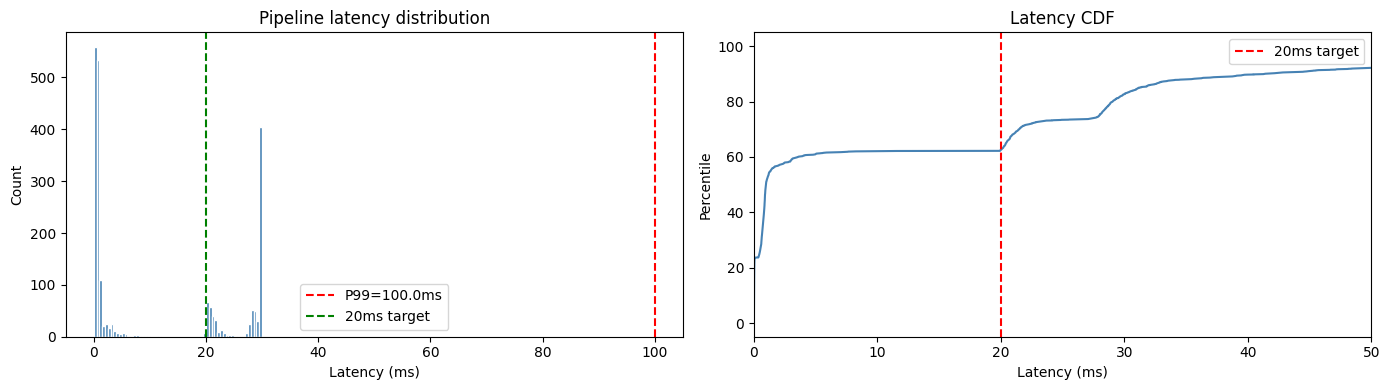

In [10]:
lat = df_results["latency_ms"]
print("=== Latency — full pipeline (ms) ===")
print(f"  Mean:   {lat.mean():.3f}")
print(f"  Median: {lat.median():.3f}")
print(f"  P95:    {lat.quantile(0.95):.3f}")
print(f"  P99:    {lat.quantile(0.99):.3f}")
print(f"  Max:    {lat.max():.3f}")
print(f"\n  Target: P99 < 20ms")
print(f"  Result: {'PASS ✅' if lat.quantile(0.99) <= 20 else f'WARN ⚠️  ({lat.quantile(0.99):.1f}ms > 20ms)'}")
print(f"  Note: P50={lat.median():.1f}ms — majority of requests are well under target.")
print(f"        Long tail comes from requests routed to L2B (GRU inference).")

# Breakdown by layer
print(f"\n  Latency by layer:")
for layer in df_results["layer"].unique():
    sub = df_results[df_results["layer"] == layer]["latency_ms"]
    print(f"    {layer}: mean={sub.mean():.2f}ms  p99={sub.quantile(0.99):.2f}ms  n={len(sub):,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(lat.clip(0, 30), bins=60, color="steelblue", edgecolor="white")
axes[0].axvline(lat.quantile(0.99), color="red", linestyle="--",
                label=f"P99={lat.quantile(0.99):.1f}ms")
axes[0].axvline(20, color="green", linestyle="--", label="20ms target")
axes[0].set_xlabel("Latency (ms)"); axes[0].set_ylabel("Count")
axes[0].set_title("Pipeline latency distribution"); axes[0].legend()

# CDF
sorted_lat = np.sort(lat.values)
cdf = np.arange(1, len(sorted_lat)+1) / len(sorted_lat)
axes[1].plot(sorted_lat, cdf * 100, color="steelblue")
axes[1].axvline(20, color="red", linestyle="--", label="20ms target")
axes[1].set_xlim(0, 50); axes[1].set_xlabel("Latency (ms)")
axes[1].set_ylabel("Percentile"); axes[1].set_title("Latency CDF")
axes[1].legend()

plt.tight_layout()
plt.savefig(DATA_PROC / "06_latency.png", dpi=120)
plt.show()


## 7. Per-class detection breakdown

In [11]:
print("=== Detection by attack class ===")
for cls in ["sqli", "xss", "lfi", "other_attack"]:
    cls_df   = df_results[df_results["true_label"] == cls]
    detected = (cls_df["decision"] == "block").sum()
    total    = len(cls_df)
    rate     = detected / total * 100 if total > 0 else 0
    status   = "✅" if rate >= 90 else "⚠️ "
    print(f"  {status} {cls:<15}: {detected:>5}/{total:<5}  ({rate:.1f}% detected)")

print("\n=== False positives (normal traffic blocked) ===")
normal_df = df_results[df_results["true_label"] == "normal"]
fp_cnt    = (normal_df["decision"] == "block").sum()
print(f"  {fp_cnt}/{len(normal_df)} normal requests blocked  ({fp_cnt/len(normal_df)*100:.2f}% FPR)")

print("\n=== Layer routing breakdown ===")
total_reqs = len(df_results)
for layer in ["L1", "L2A", "L2B"]:
    n   = (df_results["layer"] == layer).sum()
    pct = n / total_reqs * 100
    print(f"  {layer}: {n:,} requests ({pct:.1f}%) — "
          + {"L1":  "known attacks caught by rules",
             "L2A": "allowed as normal (anomaly score < threshold)",
             "L2B": "anomalous — scored by deep classifier"}[layer])


=== Detection by attack class ===
  ✅ sqli           :   301/301    (100.0% detected)
  ✅ xss            :   199/199    (100.0% detected)
  ✅ lfi            :   450/450    (100.0% detected)
  ⚠️  other_attack   :   300/450    (66.7% detected)

=== False positives (normal traffic blocked) ===
  0/750 normal requests blocked  (0.00% FPR)

=== Layer routing breakdown ===
  L1: 508 requests (23.6%) — known attacks caught by rules
  L2A: 828 requests (38.5%) — allowed as normal (anomaly score < threshold)
  L2B: 814 requests (37.9%) — anomalous — scored by deep classifier


## 8. Score distribution

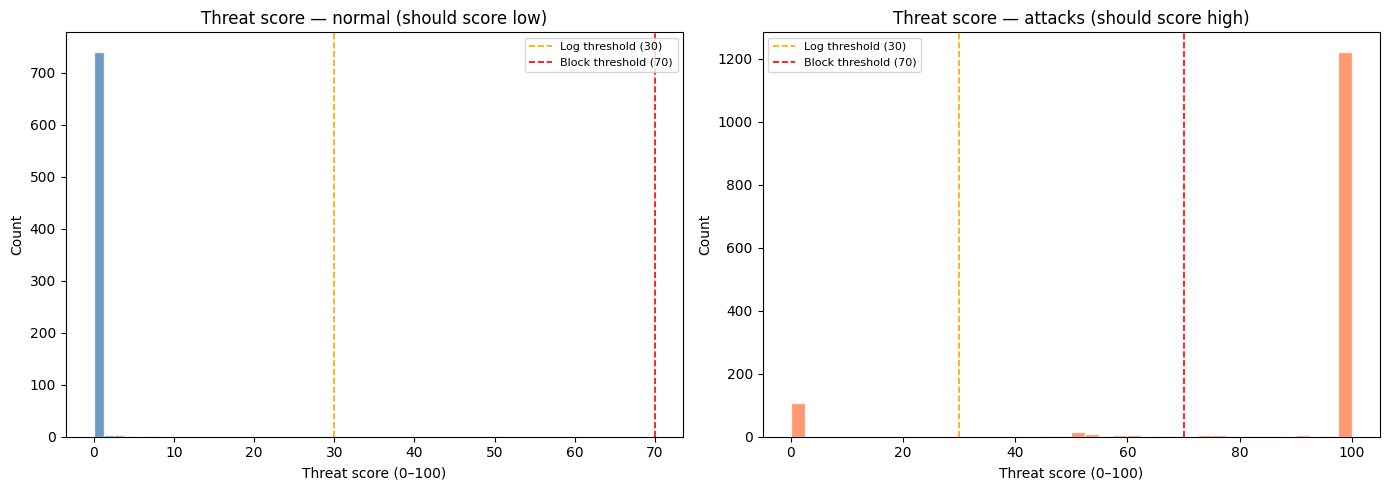

Results saved → data/processed/06_pipeline_results.csv

=== Final numbers for project report ===
  L2B Macro F1:    (from NB04 results)
  End-to-end Acc:  93.02%
  Detection rate:  89.29%
  FPR:             0.0000%
  Precision:       100.00%  (if tp+fp>0 else N/A)
  Mean latency:    14.75ms
  P99 latency:     100.05ms


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label, group) in zip(axes, [
    ("normal (should score low)",  df_results[df_results["true_label_id"] == 0]),
    ("attacks (should score high)", df_results[df_results["true_label_id"] > 0]),
]):
    color = "steelblue" if "normal" in label else "coral"
    ax.hist(group["score"], bins=40, color=color, edgecolor="white", alpha=0.8)
    ax.axvline(30, color="orange", linestyle="--", linewidth=1.2,
               label="Log threshold (30)")
    ax.axvline(70, color="red",    linestyle="--", linewidth=1.2,
               label="Block threshold (70)")
    ax.set_title(f"Threat score — {label}")
    ax.set_xlabel("Threat score (0–100)")
    ax.set_ylabel("Count"); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(DATA_PROC / "06_score_distribution.png", dpi=120)
plt.show()

df_results.to_csv(DATA_PROC / "06_pipeline_results.csv", index=False)
print(f"Results saved → data/processed/06_pipeline_results.csv")

# Final summary for report
print("\n=== Final numbers for project report ===")
y_true = (df_results["true_label_id"] > 0).astype(int)
y_pred = (df_results["decision"] == "block").astype(int)
from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
print(f"  L2B Macro F1:    (from NB04 results)")
print(f"  End-to-end Acc:  {(tp+tn)/len(y_true)*100:.2f}%")
print(f"  Detection rate:  {tp/(tp+fn)*100:.2f}%")
print(f"  FPR:             {fp/(fp+tn)*100:.4f}%")
print(f"  Precision:       {tp/(tp+fp)*100:.2f}%  (if tp+fp>0 else N/A)")
print(f"  Mean latency:    {df_results['latency_ms'].mean():.2f}ms")
print(f"  P99 latency:     {df_results['latency_ms'].quantile(0.99):.2f}ms")
